In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from dtwpair.utils.dtw_distance import SquaredDtwDistance
from dtwpair import SlidingWindowDtwPair

In [ ]:
def make_lead_diff_heatmap(dtwp,
                           baboonCoordinates: np.ndarray, 
                           x_window_size: int,
                           y_window_size: int, 
                           top_k: int=1) -> np.ndarray:
  """
  Compute lead difference of baboons.
  Parameters
  ----------
  dtwp
      Object used to compute most similar subsequences.
  baboonCoordinates : np.ndarray
      Time series of baboons' coordinates.
  x_window_size : int
      Window size of subsequences from the first time series.
  y_window_size : int
      Window size of subsequences from the second time series.
  top_k : int
      Number of most similar subsequences used to compute lead difference.
  Returns
  -------
  np.ndarray
      Matrix of lead difference.
  """

  num_baboon = len(baboonCoordinates)
  lead_diff = np.zeros((num_baboon, num_baboon))

  for i in range(num_baboon):
    for j in range(i):
      res, _ = dtwp.subsequence_nearest_neighbour(baboonCoordinates[i], baboonCoordinates[j], x_window_size, y_window_size, top_k=top_k, normalization=False)
      sub_lead = res[:, 0] - res[:, 1]
      lead_diff[i][j] = np.sum(sub_lead < 0) - np.sum(sub_lead > 0)
      lead_diff[j][i] = -lead_diff[i][j]
      
  return lead_diff

In [4]:
def show_lead_diff_heatmap(lead_diff: np.ndarray, title: str, vmin: float, vmax: float):
  norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
  colors = [(1, 0, 0), (1, 1, 1), (0, 0.5, 0)]
  custom_cmap = LinearSegmentedColormap.from_list("red_white_green", colors, N=256)

  fig = plt.figure(figsize=(8, 8), constrained_layout=True)

  ax1 = fig.add_axes([0.22, 0.4, 0.5, 0.48])
  im1 = ax1.imshow(lead_diff, cmap=custom_cmap, norm=norm, aspect='equal')
  ax1.set_title(title, fontsize=12)
  ax1.set_xlabel("Follower Baboon ID", fontsize=12)
  ax1.set_ylabel("Leader Baboon ID", fontsize=12)

  even_ticks_1 = np.arange(0, lead_diff.shape[1], 2)
  even_ticks_2 = np.arange(0, lead_diff.shape[0], 2)
  ax1.set_xticks(ticks=even_ticks_1, labels=even_ticks_1 + 1)
  ax1.set_yticks(ticks=even_ticks_2, labels=even_ticks_2 + 1)

  ax2 = fig.add_axes([0.48, 0.425, 0.3, 0.425])
  im2 = ax2.imshow(np.average(lead_diff, axis=1, keepdims=True), cmap=custom_cmap, norm=norm, aspect='equal')
  ax2.set_xticks([])
  ax2.set_yticks([])
  ax2.set_xlabel("Lead Diff Avg", fontsize=8)

  cbar = fig.colorbar(im2, ax=(ax1, ax2), orientation='vertical', fraction=0.05, pad=0.1)
  cbar.set_label("How much leader leads follower", fontsize=12)

  plt.show()

/Users/a/Documents/GitHub/dtw-pair/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


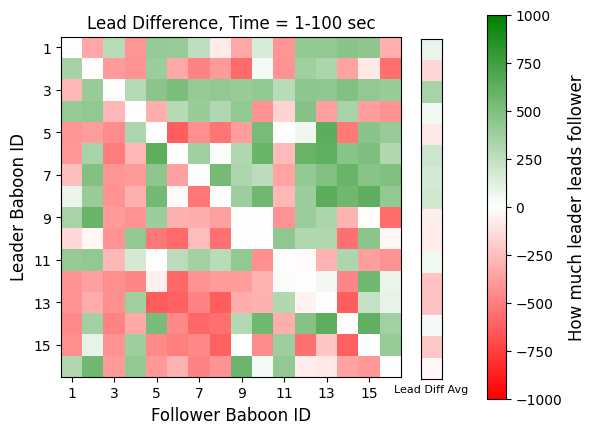

/Users/a/Documents/GitHub/dtw-pair/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


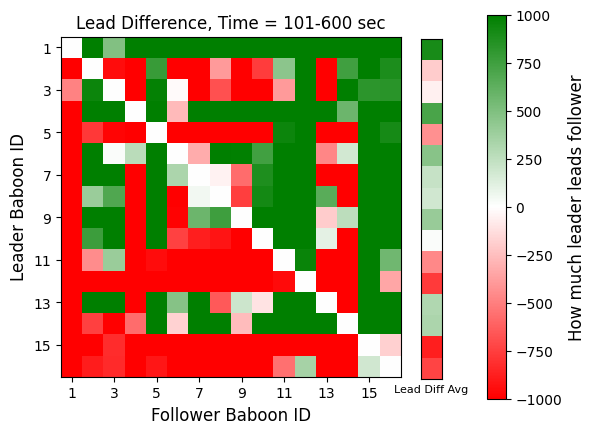

In [5]:
with open('dataset/baboon/baboonX.csv', mode ='r') as file:
  baboonX = list(csv.reader(file)) 
with open('dataset/baboon/baboonY.csv', mode ='r') as file:
  baboonY = list(csv.reader(file)) 

baboonX = np.array(baboonX[1:], dtype=np.float64)
baboonY = np.array(baboonY[1:], dtype=np.float64)
baboonCoordinates = np.stack((baboonX, baboonY), axis=2)

dtwp = SlidingWindowDtwPair(dtw_distance=SquaredDtwDistance(), verbose=False)
window_size = 60

lead_diff_t_1_100 = make_lead_diff_heatmap(dtwp, baboonCoordinates[:,:100,:], window_size, window_size, top_k=1000)
lead_diff_t_101_600 = make_lead_diff_heatmap(dtwp, baboonCoordinates[:,100:,:], window_size, window_size, top_k=1000)

vmin = min(np.min(lead_diff_t_1_100), np.min(lead_diff_t_101_600))
vmax = max(np.max(lead_diff_t_1_100), np.max(lead_diff_t_101_600))

show_lead_diff_heatmap(lead_diff_t_1_100, "Lead Difference, Time = 1-100 sec", vmin, vmax)
show_lead_diff_heatmap(lead_diff_t_101_600, "Lead Difference, Time = 101-600 sec", vmin, vmax)